In [10]:
import pandas as pd

df = pd.read_csv('titanic.csv')
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

In [11]:
# Check missing
df.isna().sum()

# Fill Age with median
median_age = df['Age'].median()
# df['Age'].fillna(median_age, inplace=True)
df['Age'] = df['Age'].fillna(median_age)

# Drop rows with missing Embarked
# df.dropna(subset=['Embarked'], inplace=True)
df = df.dropna(subset=['Embarked'])

In [12]:
# Convert Pclass and Survived to category
df['Pclass'] = df['Pclass'].astype('category')
df['Survived'] = df['Survived'].astype('category')


In [13]:
print(df.describe())
print(df['Survived'].value_counts(normalize=True))


       PassengerId         Age       SibSp       Parch        Fare
count   889.000000  889.000000  889.000000  889.000000  889.000000
mean    446.000000   29.315152    0.524184    0.382452   32.096681
std     256.998173   12.984932    1.103705    0.806761   49.697504
min       1.000000    0.420000    0.000000    0.000000    0.000000
25%     224.000000   22.000000    0.000000    0.000000    7.895800
50%     446.000000   28.000000    0.000000    0.000000   14.454200
75%     668.000000   35.000000    1.000000    0.000000   31.000000
max     891.000000   80.000000    8.000000    6.000000  512.329200
Survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [14]:
# Survival rate by class
df['Survived'] = pd.to_numeric(df['Survived'])
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print(survival_by_class)


Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


C:\Users\wania\AppData\Local\Temp\ipykernel_4844\2383696885.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class = df.groupby('Pclass')['Survived'].mean()


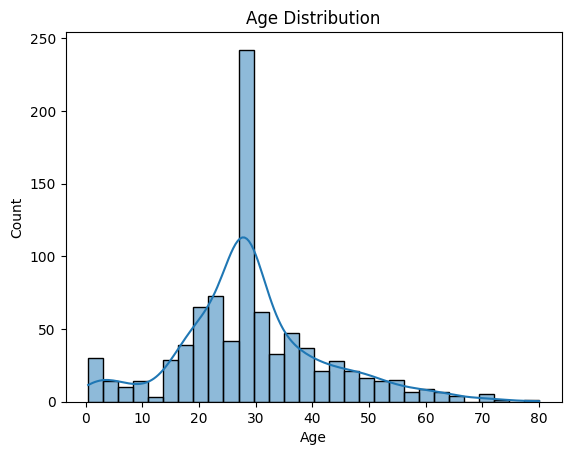

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()


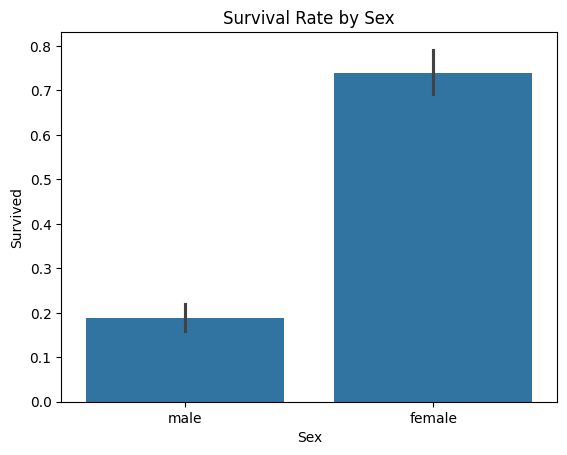

In [16]:
# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()


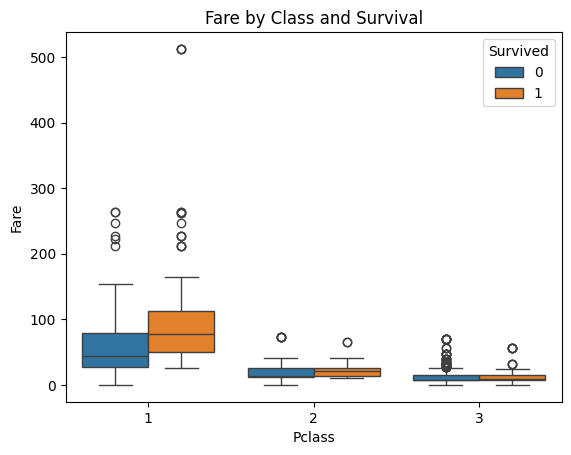

In [17]:
# Boxplot of Fare by Pclass and Survived
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)
plt.title('Fare by Class and Survival')
plt.show()
